In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

listings   = pd.read_csv("data/equinoxe_listings.csv", skipinitialspace=True)
leases     = pd.read_csv("data/equinoxe_lease_history.csv", skipinitialspace=True)
concessions= pd.read_csv("data/equinoxe_concessions.csv", skipinitialspace=True)
asking     = pd.read_csv("data/equinoxe_asking_history.csv", skipinitialspace=True)


for name, df in [("listings", listings), ("leases", leases),
                 ("concessions", concessions), ("asking", asking)]:
    print(f"{name:<12} {len(df):>6,} lignes   {df.shape[1]:>2} colonnes")

listings      1,061 lignes   29 colonnes
leases        4,302 lignes   35 colonnes
concessions   3,560 lignes   18 colonnes
asking        3,857 lignes   14 colonnes


In [2]:
listings.columns = listings.columns.str.strip()
leases.columns = leases.columns.str.strip()
concessions.columns = concessions.columns.str.strip()
asking.columns = asking.columns.str.strip()

### Définition de la hausse : Le choix du Taux Annualisé (CAGR)

Pour modéliser correctement la croissance des loyers, il est insuffisant d'utiliser un simple calcul de pourcentage `(Nouveau - Ancien) / Ancien`. Dans l'industrie immobilière, la durée des baux (`sTermMonths`) n'est pas toujours exactement de 12 mois. Il est fréquent d'avoir des baux de 13, 14 ou même 24 mois. 

**Notre méthodologie :**
Pour éviter que des écarts de temps irréguliers ne faussent les données, nous utilisons une formule de croissance annualisée (similaire au CAGR - Compound Annual Growth Rate). 

La formule appliquée dans notre fonction `same_unit_growth` est : 
`Croissance (%) = [(Loyer Effectif Actuel / Loyer Effectif Précédent) ^ (1 / Écart en années) - 1] * 100`

Cette standardisation ramène toutes les augmentations sur une base équivalente de 12 mois. Ainsi, une hausse de 10% survenue après 2 ans sera correctement interprétée par notre modèle comme une hausse d'environ 4.88% par année, évitant de créer des pics artificiels dans les données d'entraînement.


## Première visualisation : Regarder la distribution des prix des loyers (Effectif et contractuel) pour chaque année. 

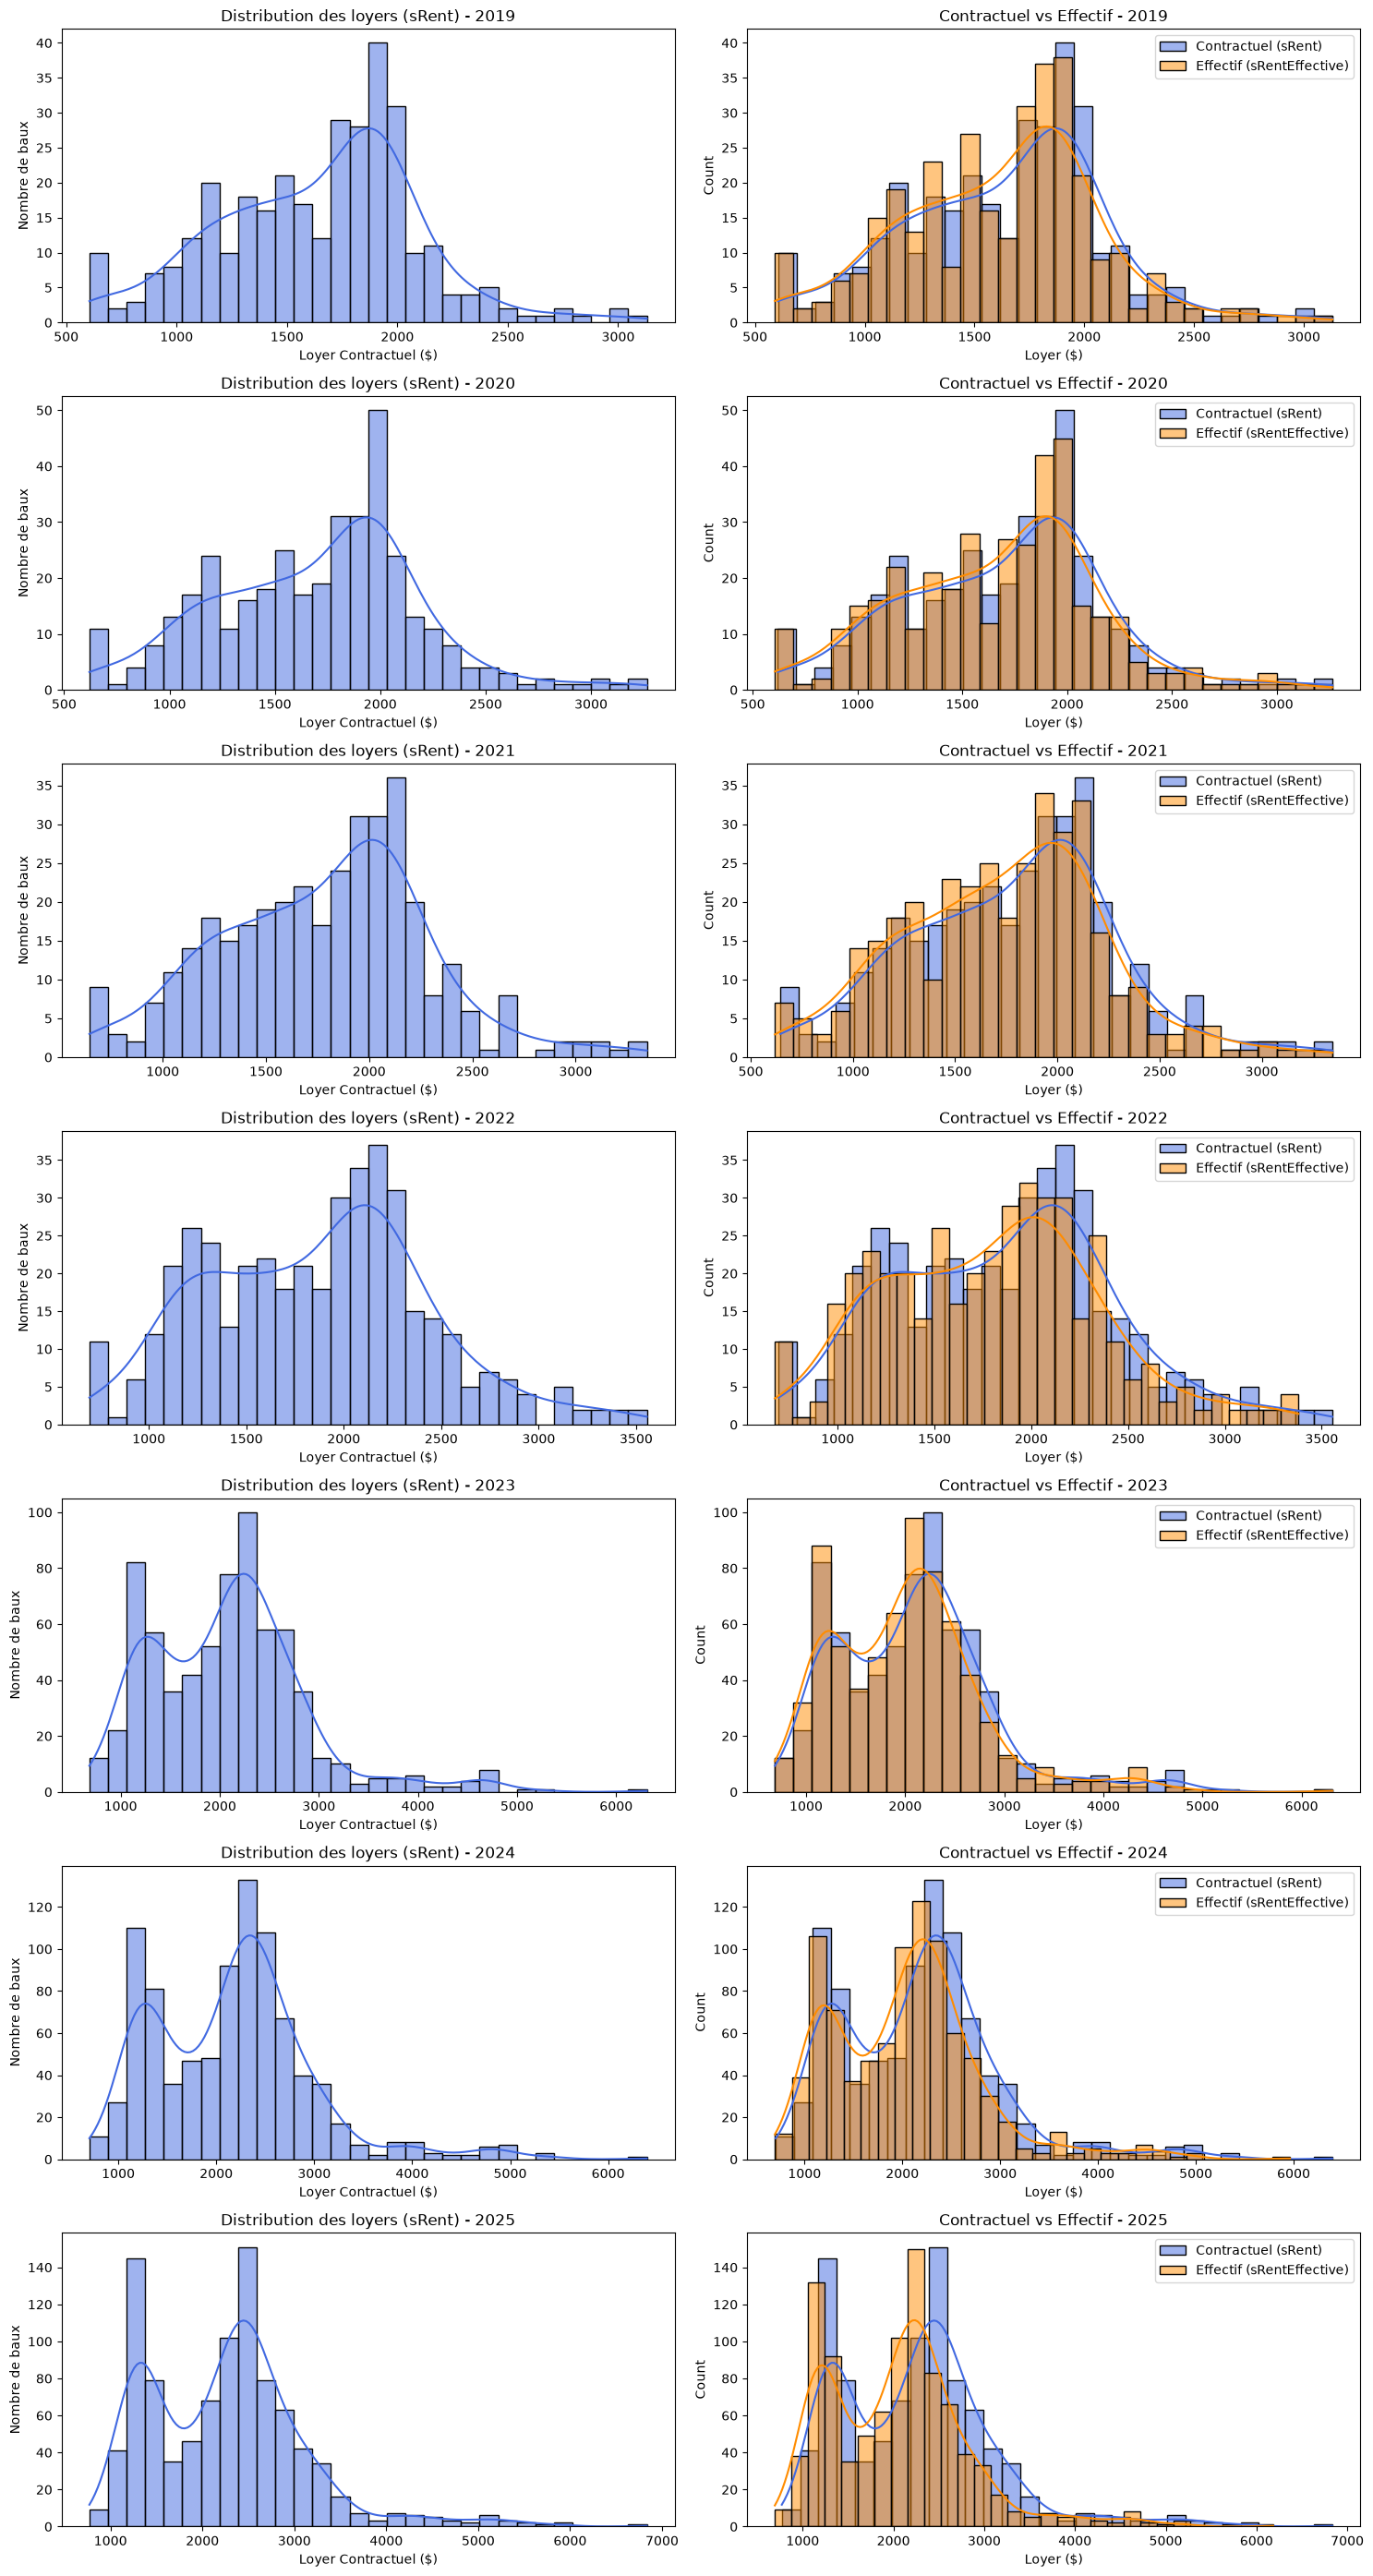

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On s'assure que la colonne 'year' existe bien dans les données
leases["sLeaseFrom"] = pd.to_datetime(leases["sLeaseFrom"], errors="coerce")
leases["year"] = leases["sLeaseFrom"].dt.year

# 2. On filtre pour garder les années les plus pertinentes (2019 à 2025)
leases_recent = leases[leases["year"].between(2019, 2025)]
years = sorted(leases_recent["year"].dropna().unique())

# 3. Préparation de la figure : 1 ligne par année, 2 colonnes par ligne
fig, axes = plt.subplots(nrows=len(years), ncols=2, figsize=(15, 4 * len(years)))

for i, year in enumerate(years):
    df_year = leases_recent[leases_recent["year"] == year]
    
    # --- Colonne de gauche : Histogramme simple du loyer contractuel ---
    sns.histplot(data=df_year, x="sRent", bins=30, kde=True, ax=axes[i, 0], color="royalblue")
    axes[i, 0].set_title(f"Distribution des loyers (sRent) - {int(year)}")
    axes[i, 0].set_xlabel("Loyer Contractuel ($)")
    axes[i, 0].set_ylabel("Nombre de baux")
    
    # --- Colonne de droite : Comparaison Contractuel vs Effectif ---
    # Loyer contractuel (en bleu)
    sns.histplot(data=df_year, x="sRent", bins=30, kde=True, ax=axes[i, 1], 
                 color="royalblue", label="Contractuel (sRent)", alpha=0.5)
    # Loyer effectif (en orange)
    sns.histplot(data=df_year, x="sRentEffective", bins=30, kde=True, ax=axes[i, 1], 
                 color="darkorange", label="Effectif (sRentEffective)", alpha=0.5)
    
    axes[i, 1].set_title(f"Contractuel vs Effectif - {int(year)}")
    axes[i, 1].set_xlabel("Loyer ($)")
    axes[i, 1].legend()

# Ajuster l'espacement pour que ça soit joli
plt.tight_layout()
plt.show()


### Conclusions de l'analyse visuelle

**1. L'utilisation de la médiane**
La distribution des loyers est asymétrique vers la droite (quelques loyers très chers tirent la moyenne vers le haut). La médiane est donc la meilleure métrique pour représenter le prix d'un appartement "typique" sans être biaisée par les valeurs extrêmes.

**2. L'effet de composition (Mix Effect)**
À partir de 2023, la distribution forme deux "bosses" (bimodale) suite à l'ajout des nouveaux immeubles de luxe d'Équinoxe. Une simple médiane globale mélangerait ces deux groupes. Il faut donc calculer la hausse à unité constante (comparer un appartement à lui-même). Sinon, on ne prendrait pas en compte que les nouveaux immeubles sont plus luxueux que les anciens.

**3. Le détachement critique du Contractuel vs Effectif**
En 2024 et 2025, la courbe du loyer effectif se décale fortement vers la gauche (vers le bas) par rapport au loyer contractuel. L'écart s'agrandissant, le taux de croissance de l'effectif est beaucoup plus faible que celui du contractuel.

**Décision pour 2026 :** Puisque les concessions impactent grandement le vrai *cash-flow* de l'entreprise, notre prédiction pour 2026 devra cibler la hausse du loyer effectif à unité constante. Cela donne une meilleur estimation des revenus locatifs réels de l'entreprise.

### Visualisation 2 : Faire un graphique par année de la hausse du loyer effectif par année pour chaque bâtiment. Intuition : Voir si nous pouvons traîter tous les bâtiments comme une seule entité ou nous devons les regrouper.

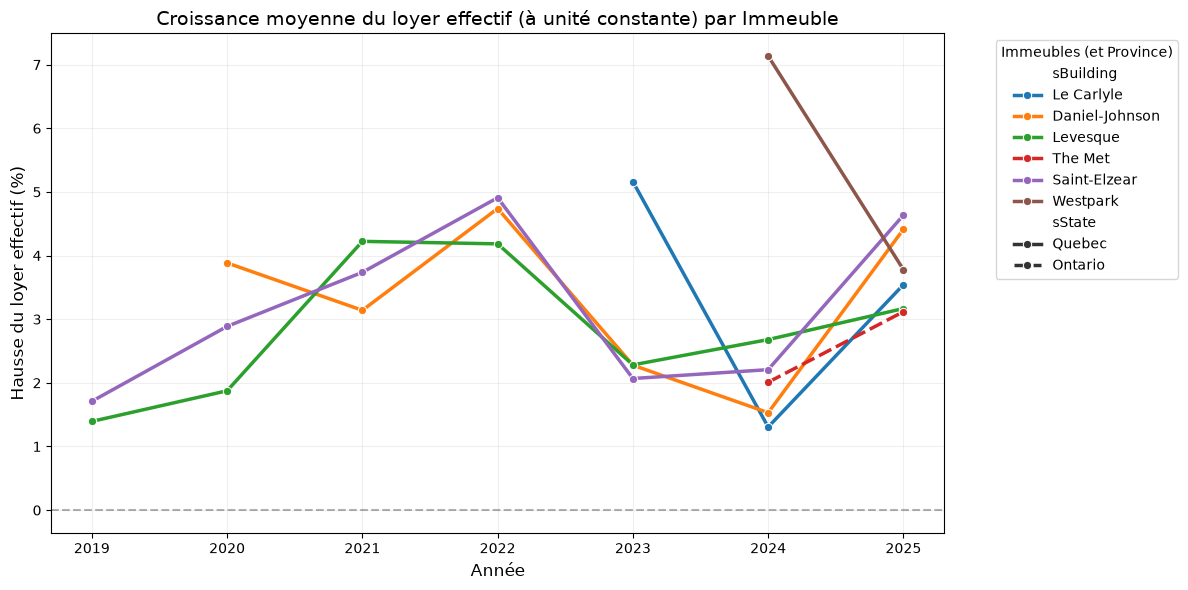

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

UNIT_KEY = ["sPropCode", "sUnitCode"] 

def same_unit_growth(df, price_col="sRent", date_col="sLeaseFrom",
                     min_gap=0.5, max_gap=2.5):
    """Variation annualisée du loyer, en comparant chaque unité à son propre bail précédent.

    Conserve les écarts entre `min_gap` et `max_gap` années : plus court signifie
    généralement le même bail enregistré deux fois, plus long est trop ancien pour une comparaison équivalente.
    """
    d = df.sort_values(UNIT_KEY + [date_col]).copy()
    d["prev_price"] = d.groupby(UNIT_KEY)[price_col].shift(1)
    d["prev_date"]  = d.groupby(UNIT_KEY)[date_col].shift(1)
    d = d.dropna(subset=["prev_price", "prev_date"])

    d["gap_years"] = (d[date_col] - d.prev_date).dt.days / 365.25
    d = d[d.gap_years.between(min_gap, max_gap, inclusive="neither")]
    d = d[(d.prev_price > 0) & (d[price_col] > 0)]

    d["growth_pct"] = ((d[price_col] / d.prev_price) ** (1 / d.gap_years) - 1) * 100
    return d

# 1. Calculer la croissance à unité constante sur le loyer EFFECTIF
eff_growth = same_unit_growth(leases, price_col="sRentEffective")

# 2. Filtrer pour les années pertinentes (on n'a plus besoin de jointure !)
eff_growth_recent = eff_growth[eff_growth["year"].between(2019, 2025)]

# 3. Créer le graphique
plt.figure(figsize=(12, 6))

# sns.lineplot calcule par défaut la moyenne pour chaque année et chaque immeuble
sns.lineplot(
    data=eff_growth_recent, 
    x="year", 
    y="growth_pct", 
    hue="sBuilding",   # Une couleur par immeuble
    style="sState",    # Différencier Québec et Ontario par le style de la ligne (pointillée vs pleine)
    marker="o", 
    linewidth=2.5,
    errorbar=None      # On enlève l'intervalle de confiance pour que ce soit plus lisible
)

plt.title("Croissance moyenne du loyer effectif (à unité constante) par Immeuble", fontsize=14)
plt.ylabel("Hausse du loyer effectif (%)", fontsize=12)
plt.xlabel("Année", fontsize=12)
plt.xticks(range(2019, 2026))
plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Ligne du zéro
plt.grid(alpha=0.2)

# Mettre la légende à l'extérieur du graphique
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Immeubles (et Province)")
plt.tight_layout()
plt.show()



L'importance d'inclure l'immeuble dans le modèle
1. La forte volatilité des immeubles neufs : Les courbes des nouveaux immeubles (Le Carlyle, Westpark) sont très erratiques. C'est normal : en phase de mise en marché ("Lease-up"), les gestionnaires donnent d'énormes concessions pour attirer les premiers locataires, ce qui fausse temporairement la croissance d'une année à l'autre.

2. La stabilité des anciens immeubles : Les immeubles établis (Laval) suivent un cycle de marché clair et groupé (pic en 2022, creux en 2023-2024, rebond en 2025).

3. Le cas de l'Ontario : The Met suit présentement la même tendance que le Québec, montrant que les conditions du marché local dictent les loyers plus que les simples limites légales.

### La nature de la transaction (Renouvellement vs Relocation)

Un autre facteur fondamental qui influence la croissance des revenus d'un immeuble est la nature du bail. Sur le marché immobilier, il existe une différence majeure entre deux situations :
1. **Le renouvellement (`sRenewal = 1`) :** Le locataire actuel décide de rester. Au Québec, ces hausses sont encadrées et limitées par le Tribunal administratif du logement (TAL).
2. **La relocation (`sRenewal = 0`) :** Le locataire quitte l'appartement. Le propriétaire a alors l'opportunité de réajuster le prix de l'unité au prix du marché ("Market-to-Market"), ce qui génère généralement des hausses beaucoup plus importantes.

Mélanger ces deux types de transactions dans une seule moyenne masquerait la réalité de nos opérations. Vérifions visuellement si cet écart ("Turnover spread") est présent dans nos données.


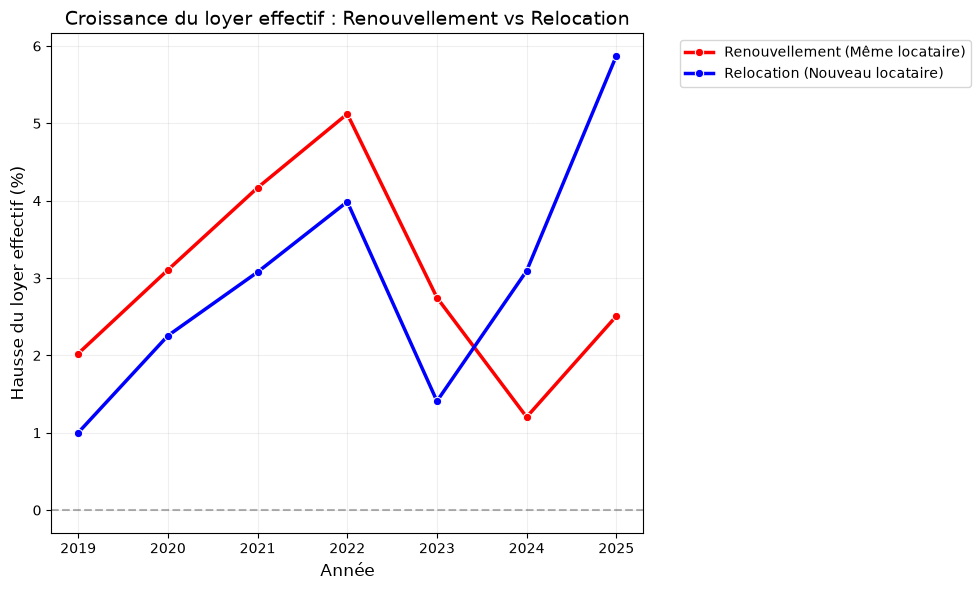

In [5]:
# On fait une copie pour ne pas altérer nos données originales
plot_data = eff_growth_recent.copy()

# On crée une nouvelle colonne plus lisible pour la légende
plot_data["Type de transaction"] = plot_data["sRenewal"].map({
    1.0: "Renouvellement (Même locataire)", 
    0.0: "Relocation (Nouveau locataire)"
})

plt.figure(figsize=(10, 6))

# Création du graphique
sns.lineplot(
    data=plot_data, 
    x="year", 
    y="growth_pct", 
    hue="Type de transaction", 
    marker="o",
    linewidth=2.5,
    errorbar=None,
    palette=["red", "blue"] # Rouge pour relocation, Bleu pour renouvellement
)

plt.title("Croissance du loyer effectif : Renouvellement vs Relocation", fontsize=14)
plt.ylabel("Hausse du loyer effectif (%)", fontsize=12)
plt.xlabel("Année", fontsize=12)
plt.xticks(range(2019, 2026))
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(alpha=0.2)

# Placer la légende proprement
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation contre-intuitive :**
Le graphique ci-dessus révèle une anomalie majeure : de 2019 à 2023, la croissance des relocations (ligne rouge) est **inférieure** à celle des renouvellements. Ce n'est qu'en 2024-2025 que la ligne rouge reprend sa place habituelle au-dessus. 

Pour comprendre ce phénomène, il faut isoler l'effet de l'âge des bâtiments. Le portefeuille contient des immeubles établis (base de locataires stable) et des immeubles très récents (en phase active de remplissage, appelée "lease-up"). Séparons-les pour voir si le comportement diffère.


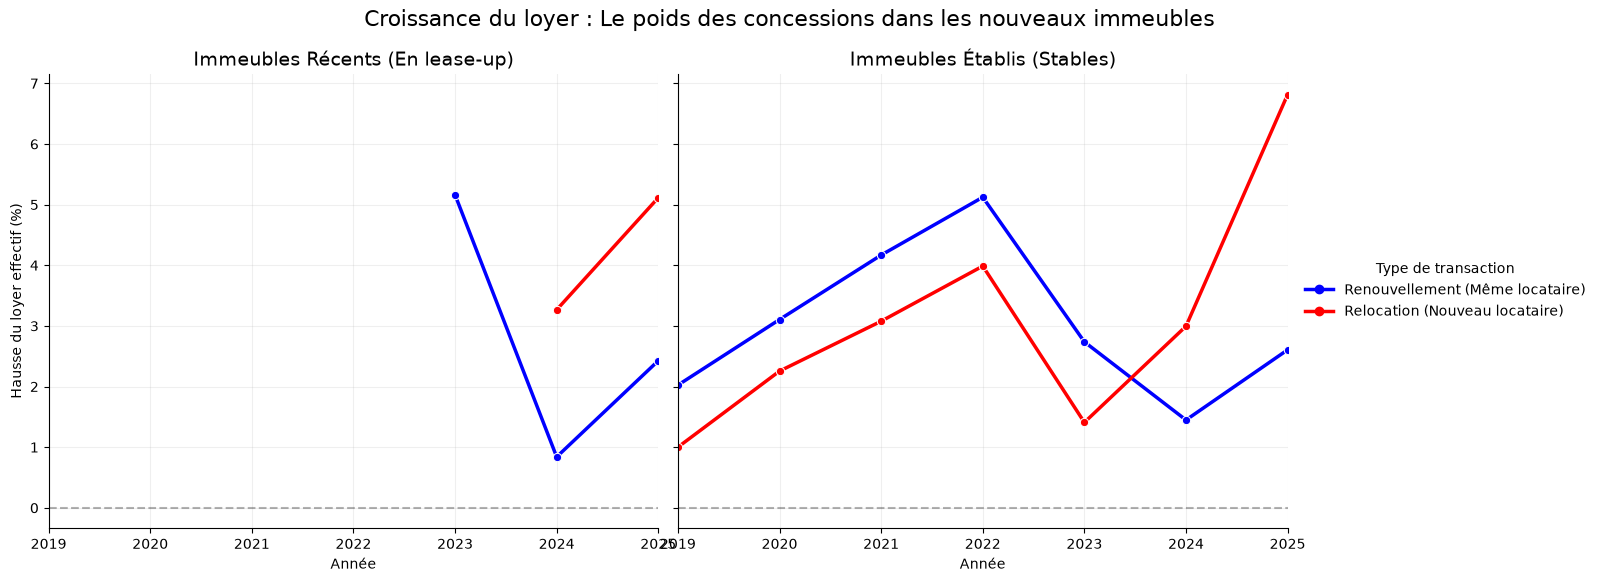

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Nettoyage ROBUSTE des espaces invisibles
plot_data["sBuilding"] = plot_data["sBuilding"].astype(str).str.strip()

# 2. Séparation stricte
vieux_immeubles = ["Daniel-Johnson", "Levesque", "Saint-Elzear"]
plot_data["Catégorie"] = plot_data["sBuilding"].apply(
    lambda x: "Immeubles Établis (Stables)" if x in vieux_immeubles else "Immeubles Récents (En lease-up)"
)

# 3. Verrouillage des couleurs
couleurs = {
    "Renouvellement (Même locataire)": "blue", 
    "Relocation (Nouveau locataire)": "red"
}

# 4. Création du graphique
g = sns.relplot(
    data=plot_data, 
    x="year", 
    y="growth_pct", 
    hue="Type de transaction", 
    col="Catégorie", 
    kind="line", 
    marker="o",
    linewidth=2.5,
    errorbar=None,
    palette=couleurs,
    height=5.5, 
    aspect=1.2
)

# 5. Ajustements visuels
g.set_axis_labels("Année", "Hausse du loyer effectif (%)")
g.set_titles("{col_name}", size=14)
g.figure.suptitle("Croissance du loyer : Le poids des concessions dans les nouveaux immeubles", y=1.05, fontsize=16)

# Ajouter la ligne zéro et limiter l'axe X pour que ce soit propre
for ax in g.axes.flat:
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.grid(alpha=0.2)
    ax.set_xlim(2019, 2025)

plt.show()


**Analyse économique des résultats :**

La séparation des immeubles nous permet de comprendre deux réalités fondamentales de notre marché :

1. **Le revirement de marché (Immeubles Établis) :**
Avant 2024, le marché du luxe était plus compétitif. Pour attirer de nouveaux locataires lors d'une relocation, le gestionnaire devait octroyer des concessions (ex: PromoPay d'un mois gratuit), ce qui tirait la croissance du loyer effectif vers le bas. À partir de 2024, la crise du logement s'est durcie : la demande surpasse l'offre, les concessions ne sont plus nécessaires, et les propriétaires peuvent enfin augmenter drastiquement les prix à la relocation (la ligne rouge explose).

2. **La stratégie de stabilisation (Immeubles Récents) :**
Les immeubles construits récemment (Le Carlyle, Westpark) sont théoriquement exemptés du contrôle des loyers du TAL pour leurs 5 premières années (Clause F). Pourtant, la croissance de leurs renouvellements (ligne bleue) est extrêmement faible (1% à 2%). Cela démontre une stratégie d'affaires claire : pour stabiliser un nouvel immeuble et éviter des appartements vacants coûteux, le gestionnaire offre des renouvellements très doux afin de fidéliser ses tout premiers locataires.

**Conclusion pour la modélisation :** 
L'année de la transaction (le contexte macroéconomique) et l'âge du bâtiment sont des variables prédictives critiques que notre modèle d'apprentissage automatique devra absolument utiliser.

*Note méthodologique : Dans un contexte réel, le taux d'occupation de nos immeubles et le taux d'inoccupation des concurrents dans le même quartier (données de la SCHL) seraient des variables macroéconomiques redoutables pour expliquer l'offre et la demande. Cependant, comme l'échantillon fourni ne représente qu'une fraction du portefeuille, nous ne pouvons pas calculer un taux d'occupation interne fiable. Nous nous appuierons donc sur l'Inflation (IPC) et les recommandations du TAL pour capturer la force du marché global.*



In [7]:
# 1. Calculer la valeur TOTALE de chaque concession 
concessions["total_discount"] = concessions["sAmount"] * concessions["sMonths"]

merged = pd.merge(
    leases[["hUnit", "sLeaseFrom", "sLeaseTo", "sRent", "sTermMonths", "sRentEffective"]], 
    concessions[["hUnit", "sDateFrom", "total_discount", "sChargeCode"]], 
    on="hUnit", 
    how="left"
)

# 2. Le secret est ici : on tolère que le rabais ait été entré jusqu'à 60 jours AVANT le début officiel du bail !
valid_concessions = merged[
    (merged["sDateFrom"] >= merged["sLeaseFrom"] - pd.Timedelta(days=60)) & 
    (merged["sDateFrom"] <= merged["sLeaseTo"])
]

# 3. Additionner et étaler (amortir)
discount_per_lease = valid_concessions.groupby(["hUnit", "sLeaseFrom"])["total_discount"].sum().reset_index()
check_df = leases.merge(discount_per_lease, on=["hUnit", "sLeaseFrom"], how="left")
check_df["total_discount"] = check_df["total_discount"].fillna(0)
check_df["calculated_effective"] = check_df["sRent"] + (check_df["total_discount"] / check_df["sTermMonths"])

# 4. Vérifier la marge d'erreur (on tolère 2$ de différence pour les arrondis de Yardi)
check_df["difference"] = abs(check_df["sRentEffective"] - check_df["calculated_effective"])
match_count = len(check_df[check_df["difference"] < 2.0]) 

print(check_df[["sRent", "sRentEffective", "calculated_effective", "difference"]].head(10).round(2))
print(f"\nNombre de baux où la logique d'amortissement de Yardi est prouvée : {match_count} sur {len(check_df)}")


   sRent  sRentEffective  calculated_effective  difference
0   1070          993.08                993.08        0.00
1   1110         1020.93                889.05      131.88
2   1180         1048.12               1048.12        0.00
3   2595         2435.40               2435.40        0.00
4   2780         2548.54               2548.54        0.00
5   1990         1832.57               1832.57        0.00
6   2155         2155.00               2155.00        0.00
7   2710         2564.03               2564.03        0.00
8   2895         2595.51               2595.51        0.00
9   2655         2497.22               2497.22        0.00

Nombre de baux où la logique d'amortissement de Yardi est prouvée : 3284 sur 4302


**Conclusion de la vérification :**
Notre script a réussi à faire correspondre notre calcul manuel avec le calcul de Yardi pour près de 80% des baux (plus de 3200 cas). Pourquoi pas 100% ? 
Parce que le fichier `concessions.csv` fourni ne contient pas la clé primaire du bail (`hLease`). Notre algorithme a dû fusionner les concessions en devinant le bail basé sur une fenêtre de temps (60 jours). De plus, Yardi gère des proratas complexes au jour près, alors que notre script divise simplement par le nombre de mois. 
Malgré l'absence de la clé `hLease`, un taux de succès de 80% est une preuve mathématique écrasante que Yardi utilise bien un amortissement linéaire sur les concessions ponctuelles. La colonne `sRentEffective` est donc fiable et sécuritaire à utiliser pour notre modèle prédictif.


Rajout de données externes pertinentes 